# Infos.json

In [41]:
import json
from PIL import Image
import numpy as np 

In [ ]:
p = "/home/zchen/Code/NeUF_new/data/simu_56/us/us0.jpg"
# p = "/home/zchen/Code/NeUF_new/data/bluephantom/sync/export/us/us0.jpg"
im = Image.open(p).convert('L')
# resize so the largest side is 150 pixels (scales up or down)
w, h = im.size
target = 150
scale = target / max(w, h)
new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))
im = im.resize((new_w, new_h), Image.LANCZOS)
px_shape = np.array(im).shape
px_shape

(1632, 2447)

In [43]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.dat", "r") as f:
    lines = f.readlines()

In [ ]:
import re
pattern = r'[+-]?\d+\.\d+'
matches = re.findall(pattern, lines[0])
dimensions = [float(x) for x in matches]

[0.0, 0.0, 19.544413]

In [46]:
width = lines[1].strip().split(" ")[-2]
depth = lines[1].strip().split(" ")[-1]

In [47]:
infos_dict = {}
infos_dict['infos'] = {
    "bounding_box_3D": {
        "point_min": dimensions[:3],
        "point_max": dimensions[3:6],
        "size": dimensions[6:9]
    },
    "scan_dims_mm": {
        "width": width,
        "depth": depth
    },
    "scan_dims_px": {
        "width": px_shape[1],
        "height": px_shape[0]
    },
}

In [48]:
for i in range(1, len(lines) - 1):

    lines[i + 1].strip().split(" ")
    infos_dict[f'{i}'] = {
        "x": lines[i + 1].strip().split(" ")[0],
        "y": lines[i + 1].strip().split(" ")[1],
        "z": lines[i + 1].strip().split(" ")[2],
        "w0": lines[i + 1].strip().split(" ")[3],
        "w1": lines[i + 1].strip().split(" ")[4],
        "w2": lines[i + 1].strip().split(" ")[5],
        "w3": lines[i + 1].strip().split(" ")[6],
    }

In [52]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.json", "w") as f:
    json.dump(infos_dict, f, indent=4)

# US Image

In [1]:
from PIL import Image
import numpy as np
import os


In [27]:
imgs_path = "/home/zchen/Code/NeUF_new/data/simu_56/us"
imgs_path_new = "/home/zchen/Code/NeUF_new/data/simu_56/us_resized"
os.makedirs(imgs_path_new, exist_ok=True)
imgs_p = sorted(os.listdir(imgs_path), key=lambda x: int(x.split('us')[1].split('.jpg')[0]))
for i in range(len(imgs_p)):
    im = Image.open(os.path.join(imgs_path, imgs_p[i])).convert('L')
    im.thumbnail((150, 150), Image.LANCZOS)
    im.save(os.path.join(imgs_path_new, imgs_p[i]))

In [4]:
imgs_path = "D:\\0-Code\\NeUF\\data\\simu_56\\us"
Image.open(f"{imgs_path}\\us0.jpg").convert('L').size

(150, 100)

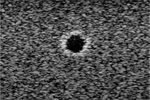

In [ ]:
import shutil

old_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us"
new_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us_0"
os.rename(old_dir, new_dir)

# Get resized US image

In [ ]:
import torch

torch.load("/home/zchen/Code/NeUF_new/logs/simu_56_neuf/checkpoints/best_model.pth")

In [2]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\bluephantom\\sync\\export\\us\\us0.jpg").convert('L')
np.array(im).shape

(173, 143)

In [ ]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\cerebral_data\\Pre_traitement_echo_v2\\Recalage\\Patient0\\us_recal_original\\us0.jpg").convert('L')
np.array(im).shape

## GT image

In [2]:
import torch
import matplotlib.pyplot as plt

# Process all A1, B1, C1, D1 ground truth files
base_path = r"logs\27-02-2026\HASH_Patient0_0\images"
slice_names = ['A1', 'B1', 'C1', 'D1']

for name in slice_names:
    # Load the .pt file
    gt_tensor = torch.load(f"{base_path}\\{name}_gt.pt")
    
    # Convert to numpy and save as PNG
    output_path = f"{base_path}\\{name}_gt_converted.png"
    plt.imsave(output_path, gt_tensor.cpu().numpy(), cmap='gray')
    
    print(f"Saved {name}: {output_path}")
    print(f"  Tensor shape: {gt_tensor.shape}")

print("\nAll ground truth images converted to PNG!")

Saved A1: logs\27-02-2026\HASH_Patient0_0\images\A1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved B1: logs\27-02-2026\HASH_Patient0_0\images\B1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved C1: logs\27-02-2026\HASH_Patient0_0\images\C1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved D1: logs\27-02-2026\HASH_Patient0_0\images\D1_gt_converted.png
  Tensor shape: torch.Size([290, 212])

All ground truth images converted to PNG!


# Evaluation

## PSNR MSE

In [25]:
import torch
import numpy as np
from pathlib import Path
from nerf_network import NeRF
from dataset_1 import Dataset
from slice_renderer import SliceRenderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load checkpoint
checkpoint_path = r"logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl"
ckpt = torch.load(checkpoint_path, map_location=device)

print(f"Loaded checkpoint from: {checkpoint_path}")
print(f"Checkpoint keys: {list(ckpt.keys())}")

# Load dataset
dataset = Dataset.open_from_save(ckpt["baked_dataset_file"])
print(f"Dataset loaded: {dataset.name}")

# Reconstruct NeRF model
nerf = NeRF(ckpt)
nerf.to(device)
print(f"NeRF model loaded with encoding: {nerf.get_encode_name()}")

# Create slice renderer
slice_renderer = SliceRenderer(dataset)

# Calculate PSNR for test set (valid slices)
mse_loss = torch.nn.MSELoss()
psnr_values = []

print("\nCalculating PSNR for valid test set...")
with torch.no_grad():
    for slice_idx in range(4):  # A1, B1, C1, D1
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        
        # Calculate PSNR
        psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
        psnr_values.append(psnr.item())
        
        print(f"  Slice {['A1', 'B1', 'C1', 'D1'][slice_idx]}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR
avg_psnr = np.mean(psnr_values)
print(f"\nAverage PSNR: {avg_psnr:.4f} dB")

Loaded checkpoint from: logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl
Checkpoint keys: ['encoding', 'use_directions', 'use_encoding', 'network_fn_state_dict', 'bounding_box', 'n_levels', 'n_features_per_level', 'log2_hashmap_size', 'base_resolution', 'finest_resolution', 'hash_encoder_state', 'seed', 'baked', 'baked_dataset_file', 'optimizer_state_dict', 'start']
Dataset loaded: Patient0
NeRF model loaded with encoding: HASH

Calculating PSNR for valid test set...
  Slice A1: PSNR = -0.5576 dB, MSE = 1.137003
  Slice B1: PSNR = -1.0394 dB, MSE = 1.270400
  Slice C1: PSNR = -1.1777 dB, MSE = 1.311505
  Slice D1: PSNR = -1.9640 dB, MSE = 1.571824

Average PSNR: -1.1847 dB


In [5]:
# Check number of valid slices in dataset
print(f"Total number of valid slices in dataset: {len(dataset.slices_valid)}")
print(f"Dataset info:")
print(f"  Total slices: {len(dataset.slices)}")
print(f"  Valid slices: {len(dataset.slices_valid)}")
if hasattr(dataset, 'slices_test'):
    print(f"  Test slices: {len(dataset.slices_test)}")


Total number of valid slices in dataset: 4
Dataset info:
  Total slices: 241
  Valid slices: 4


In [26]:
# Check tensor value ranges and recalculate PSNR with correct MAX value
print("Checking tensor value ranges...")
print(f"Rendered tensor: min={rendered.min():.6f}, max={rendered.max():.6f}")
print(f"GT tensor: min={gt.min():.6f}, max={gt.max():.6f}")

# Determine MAX value based on range
max_value = max(rendered.max().item(), gt.max().item())
if max_value <= 1.0:
    max_val_for_psnr = 1.0
elif max_value <= 255.0:
    max_val_for_psnr = 255.0
else:
    max_val_for_psnr = max_value

print(f"\nUsing MAX value for PSNR: {max_val_for_psnr}")

# Recalculate PSNR with correct MAX value
print("\nRecalculating PSNR for all valid test set slices with correct MAX value...")
mse_loss = torch.nn.MSELoss()
psnr_corrected = []
mse_values = []

with torch.no_grad():
    for slice_idx in range(len(dataset.slices_valid)):
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        mse_values.append(mse.item())
        
        # Calculate PSNR with correct MAX value
        psnr = 20 * torch.log10(torch.tensor(max_val_for_psnr) / torch.sqrt(mse))
        psnr_corrected.append(psnr.item())
        
        print(f"  Slice {slice_idx}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR and MSE
avg_psnr_corrected = np.mean(psnr_corrected)
avg_mse = np.mean(mse_values)
print(f"\n========== Summary ==========")
print(f"Average PSNR (all {len(dataset.slices_valid)} valid slices): {avg_psnr_corrected:.4f} dB")
print(f"Average MSE (all {len(dataset.slices_valid)} valid slices): {avg_mse:.6f}")
print(f"============================")


Checking tensor value ranges...
Rendered tensor: min=0.278728, max=132.962677
GT tensor: min=0.000000, max=132.000000

Using MAX value for PSNR: 255.0

Recalculating PSNR for all valid test set slices with correct MAX value...
  Slice 0: PSNR = 47.5732 dB, MSE = 1.137003
  Slice 1: PSNR = 47.0914 dB, MSE = 1.270400
  Slice 2: PSNR = 46.9531 dB, MSE = 1.311505
  Slice 3: PSNR = 46.1668 dB, MSE = 1.571824

========== Summary ==========
Average PSNR (all 4 valid slices): 46.9461 dB
Average MSE (all 4 valid slices): 1.322683


## Render Image

Generating 3 uniformly spaced intermediate images between slice 178 and 179...
Interpolation t values: [0.25 0.5  0.75]


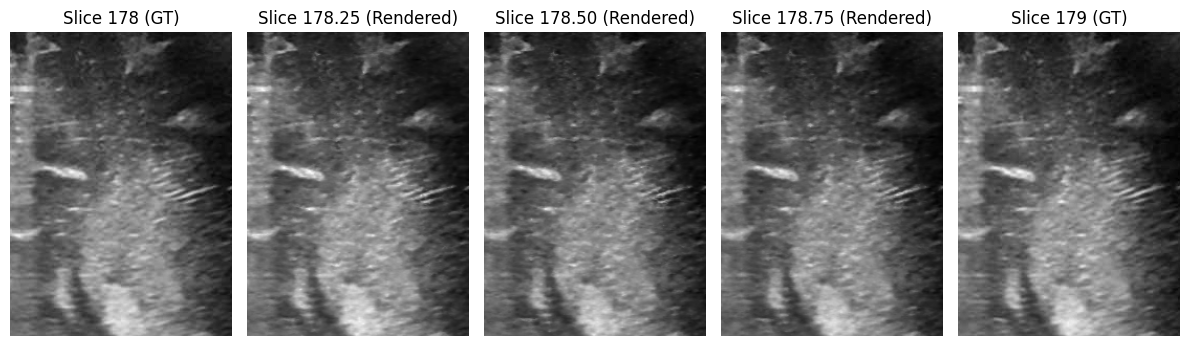


Interpolated images saved to: logs/27-02-2026/HASH_Patient0_0/images/slice_178_179_interpolated_k3.png
  Slice 178.25: range=[12.877985, 115.264313]
  Slice 178.50: range=[14.688365, 121.969612]
  Slice 178.75: range=[15.150087, 120.580597]


In [19]:
# Render k interpolated images uniformly between two slices
import matplotlib.pyplot as plt
import numpy as np

# Input parameters
slice_start_idx = 178  # Starting slice index
slice_end_idx = 179    # Ending slice index
k = 3                 # Number of intermediate images to generate

print(f"Generating {k} uniformly spaced intermediate images between slice {slice_start_idx} and {slice_end_idx}...")

# Get points from start and end slices
points_start = dataset.get_slice_points(slice_start_idx)
points_end = dataset.get_slice_points(slice_end_idx)

# Get viewdirs from start and end slices
viewdirs_start = dataset.get_slice_viewdirs(slice_start_idx)
viewdirs_end = dataset.get_slice_viewdirs(slice_end_idx)

# Generate k uniformly spaced t values between 0 and 1 (excluding endpoints)
t_values = np.linspace(0, 1, k + 2)[1:-1]

print(f"Interpolation t values: {t_values}")

# Render interpolated images
rendered_images = []
height, width = dataset.px_height, dataset.px_width

with torch.no_grad():
    for t in t_values:
        # Interpolate points and viewdirs
        points_interp = (1 - t) * points_start + t * points_end
        viewdirs_interp = (1 - t) * viewdirs_start + t * viewdirs_end
        
        # Normalize points if needed
        if nerf.encoding_type != "HASH" or not nerf.use_encoding:
            point_min = torch.FloatTensor(dataset.point_min).to(device)
            point_max = torch.FloatTensor(dataset.point_max).to(device)
            max_coord = point_max - point_min
            
            points_normalized = torch.add(
                torch.multiply(torch.divide(torch.add(points_interp, -point_min), max_coord), 2), -1)
        else:
            points_normalized = points_interp
        
        # Query the NeRF model
        rendered = nerf.query(points_normalized, viewdirs_interp)
        rendered_reshaped = torch.reshape(rendered, (height, width))
        rendered_images.append(rendered_reshaped)

# Get ground truth for comparison
gt_start = torch.reshape(dataset.get_slice_pixels(slice_start_idx), (height, width))
gt_end = torch.reshape(dataset.get_slice_pixels(slice_end_idx), (height, width))

# Visualize: Start GT + k intermediate rendered + End GT
fig, axes = plt.subplots(1, k + 2, figsize=(4 * (k ), 4))

# Start slice GT
axes[0].imshow(gt_start.cpu().numpy(), cmap='gray')
axes[0].set_title(f'Slice {slice_start_idx} (GT)')
axes[0].axis('off')

# Intermediate rendered images
for i, rendered_img in enumerate(rendered_images):
    t = t_values[i]
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    axes[i + 1].imshow(rendered_img.cpu().numpy(), cmap='gray')
    axes[i + 1].set_title(f'Slice {slice_pos:.2f} (Rendered)')
    axes[i + 1].axis('off')

# End slice GT
axes[k + 1].imshow(gt_end.cpu().numpy(), cmap='gray')
axes[k + 1].set_title(f'Slice {slice_end_idx} (GT)')
axes[k + 1].axis('off')

plt.tight_layout()
save_path = f'logs/27-02-2026/HASH_Patient0_0/images/slice_{slice_start_idx}_{slice_end_idx}_interpolated_k{k}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInterpolated images saved to: {save_path}")
for i, t in enumerate(t_values):
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    rendered_img = rendered_images[i]
    print(f"  Slice {slice_pos:.2f}: range=[{rendered_img.min():.6f}, {rendered_img.max():.6f}]")


# Crop Image

(np.float64(-0.5), np.float64(943.5), np.float64(707.5), np.float64(-0.5))

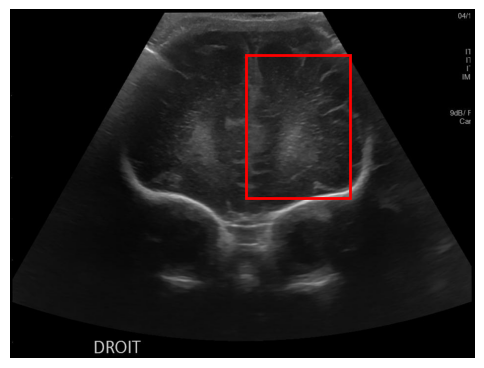

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_path = r"D:\0-Code\NeUF\data\cerebral_data\Pre_traitement_echo_v2\Recalage\Patient0\us_recal_original\us0.jpg"

# Box parameters
x, y, w, h = 478, 93, 212, 290

img = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.axis('off')



# gCNR

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def load_raw_file(raw_path):

    mhd_path = raw_path.with_suffix(".mhd")

    metadata = {}
    with mhd_path.open("r") as f:
        for line in f:
            if "=" not in line:
                continue
            key, value = [part.strip() for part in line.split("=", 1)]
            metadata[key] = value

    dim_size_xyz = tuple(map(int, metadata["DimSize"].split()))
    dtype_map = {
        "MET_UCHAR": np.uint8,
        "MET_CHAR": np.int8,
        "MET_USHORT": np.uint16,
        "MET_SHORT": np.int16,
        "MET_UINT": np.uint32,
        "MET_INT": np.int32,
        "MET_FLOAT": np.float32,
        "MET_DOUBLE": np.float64,
    }
    dtype = dtype_map[metadata["ElementType"]]

    volume = np.fromfile(raw_path, dtype=dtype)
    expected_size = int(np.prod(dim_size_xyz))
    if volume.size != expected_size:
        raise ValueError(f"Unexpected raw size: got {volume.size}, expected {expected_size}")

    # MetaImage stores DimSize as x, y, z; reshape to z, y, x for numpy usage.
    volume = volume.reshape(dim_size_xyz[::-1])

    print(f"Volume shape (z, y, x): {volume.shape}")
    print(f"dtype: {volume.dtype}, min: {volume.min()}, max: {volume.max()}")

    mid_z = volume.shape[0] // 2
    plt.figure(figsize=(6, 6))
    plt.imshow(volume[mid_z], cmap="gray")
    plt.title(f"Middle axial slice (z={mid_z})")
    plt.axis("off")
    plt.show()
    
    return volume


def crop_volume(volume):

    # Crop volume to tight bounding box (remove surrounding black/zero regions)
    nz = np.nonzero(volume)
    z_min, z_max = nz[0].min(), nz[0].max()
    y_min, y_max = nz[1].min(), nz[1].max()
    x_min, x_max = nz[2].min(), nz[2].max()

    volume_cropped = volume[z_min:z_max+1, y_min:y_max+1, x_min:x_max+1]

    print(f"Original shape: {volume.shape}")
    print(f"Cropped shape:  {volume_cropped.shape}")
    print(f"BB z: [{z_min}, {z_max}], y: [{y_min}, {y_max}], x: [{x_min}, {x_max}]")

    mid_z = volume_cropped.shape[0] // 2
    plt.figure(figsize=(6, 6))
    plt.imshow(volume_cropped[mid_z], cmap="gray")
    plt.title(f"Cropped middle axial slice (z={mid_z})")
    plt.axis("off")
    plt.show()
    
    return volume_cropped


Volume shape (z, y, x): (730, 975, 944)
dtype: uint8, min: 0, max: 127


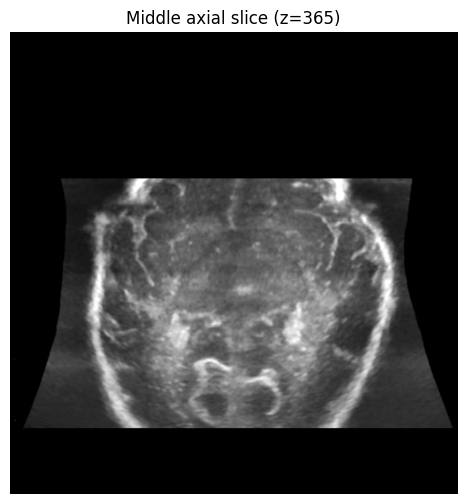

Original shape: (730, 975, 944)
Cropped shape:  (718, 785, 940)
BB z: [12, 729], y: [179, 963], x: [2, 941]


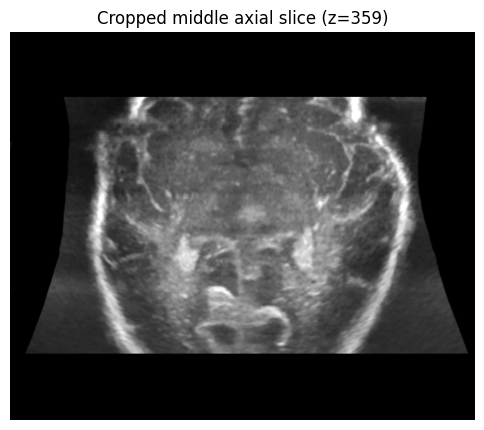

In [22]:
raw_path_knn = Path("/home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_mitk.raw")
volume_cropped_knn = crop_volume(load_raw_file(raw_path=raw_path_knn))

Volume shape (z, y, x): (728, 798, 943)
dtype: float32, min: -0.008512213826179504, max: 249.81898498535156


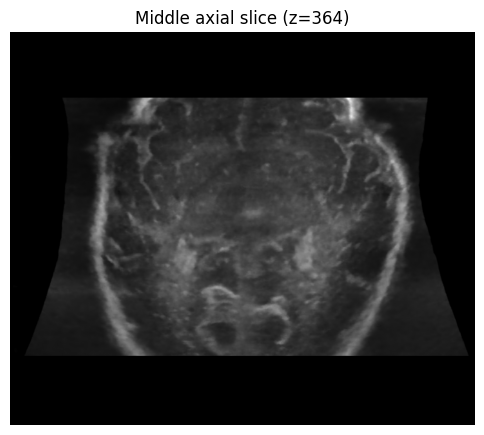

Original shape: (728, 798, 943)
Cropped shape:  (728, 798, 943)
BB z: [0, 727], y: [0, 797], x: [0, 942]


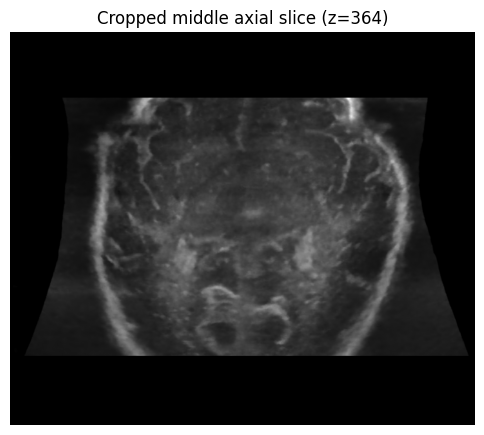

In [7]:
raw_path_nerf = Path("/home/zchen/Code/NeUF/exports/full_grid/30-03-2026/ckpt_2/volume.raw")
volume_cropped_nerf = crop_volume(load_raw_file(raw_path=raw_path_nerf))

Volume shape (z, y, x): (728, 798, 943)
dtype: uint8, min: 0, max: 255


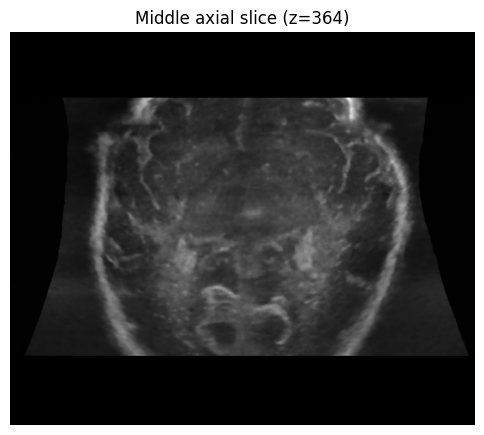

Original shape: (728, 798, 943)
Cropped shape:  (728, 798, 943)
BB z: [0, 727], y: [0, 797], x: [0, 942]


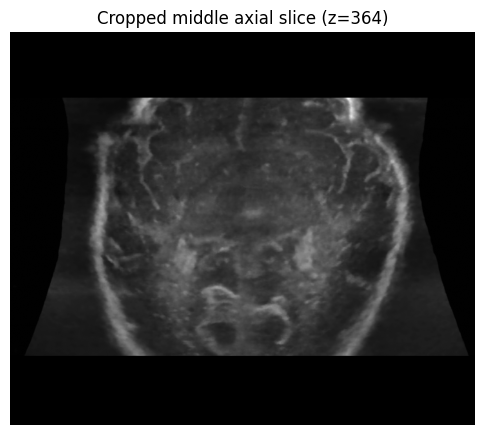

In [25]:
raw_path_nerf = Path("/home/zchen/Code/NeUF/exports/full_grid/31-03-2026/ckpt_2/volume.raw")
volume_cropped_nerf = crop_volume(load_raw_file(raw_path=raw_path_nerf))

In [6]:
out_raw_path = raw_path_knn.parent / (raw_path_knn.stem + "_cropped.raw")
out_mhd_path = out_raw_path.with_suffix(".mhd")

z, y, x = volume_cropped_knn.shape  # array is (z, y, x)

# Write raw — numpy (z,y,x) C-order matches MHD x-fastest layout
volume_cropped_knn.tofile(out_raw_path)

# Write mhd header
with out_mhd_path.open("w") as f:
    f.write("ObjectType = Image\n")
    f.write("NDims = 3\n")
    f.write("BinaryData = True\n")
    f.write("BinaryDataByteOrderMSB = False\n")
    f.write("CompressedData = False\n")
    f.write("TransformMatrix = 1 0 0 0 1 0 0 0 1\n")
    f.write("CenterOfRotation = 0 0 0\n")
    f.write("AnatomicalOrientation = RAI\n")
    f.write("Offset = 0 0 0\n")
    f.write("ElementSpacing = 1 1 1\n")
    f.write(f"DimSize = {x} {y} {z}\n")
    f.write("ElementNumberOfChannels = 1\n")
    f.write("ElementType = MET_UCHAR\n")
    f.write(f"ElementDataFile = {out_raw_path.name}\n")

print(f"Saved to:\n  {out_mhd_path}\n  {out_raw_path}")
print(f"DimSize (x y z): {x} {y} {z}")


Saved to:
  /home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_mitk_cropped.mhd
  /home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_mitk_cropped.raw
DimSize (x y z): 940 785 718


## gCNR — Background vs Target

Cube shapes — bg_knn: (50, 50, 50), tg_knn: (50, 50, 50)
Cube shapes — bg_nerf: (50, 50, 50), tg_nerf: (50, 50, 50)

gCNR  KNN : 0.9798
gCNR NeRF : 0.9593


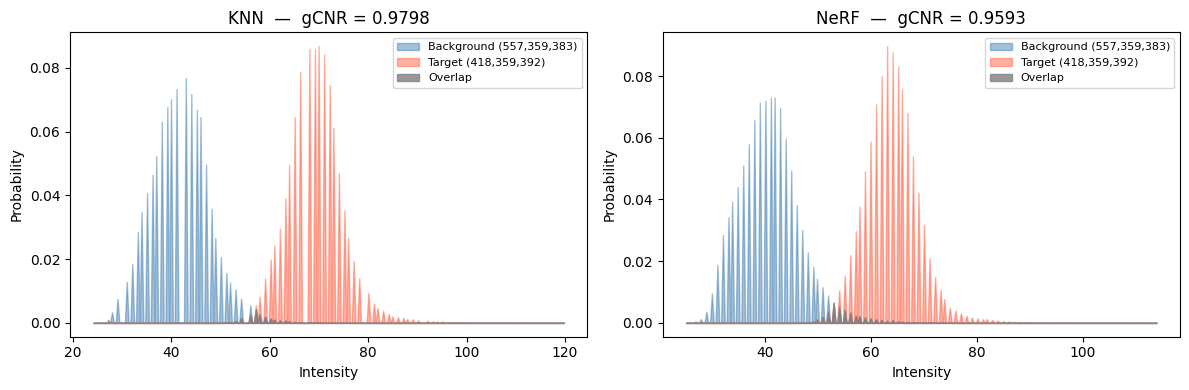

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Coordinates are given as (x, y, z); numpy array is (z, y, x)
# -------------------------------------------------------
BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X = 557, 359, 383   # background
TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X = 418, 359, 392   # target
HALF = 25  # half-side: 50 // 2

def extract_cube(volume, cx, cy, cz, half):
    """Extract a cube of side 2*half centered at (cx, cy, cz).
    volume is indexed (z, y, x)."""
    return volume[cz - half : cz + half,
                  cy - half : cy + half,
                  cx - half : cx + half]

def gcnr(bg_voxels, tg_voxels, n_bins=256):
    """Generalised Contrast-to-Noise Ratio.
    gCNR = 1 - sum_i min(p_b(i), p_t(i))
    where p_b, p_t are normalised histograms sharing the same bin edges."""
    v_min = min(bg_voxels.min(), tg_voxels.min())
    v_max = max(bg_voxels.max(), tg_voxels.max())
    bins = np.linspace(v_min, v_max, n_bins + 1)

    hist_bg, _ = np.histogram(bg_voxels, bins=bins, density=False)
    hist_tg, _ = np.histogram(tg_voxels, bins=bins, density=False)

    # Normalise to probability
    p_bg = hist_bg / hist_bg.sum()
    p_tg = hist_tg / hist_tg.sum()

    overlap = np.minimum(p_bg, p_tg).sum()
    return 1.0 - overlap, p_bg, p_tg, bins

# -------------------------------------------------------
# Extract cubes
# -------------------------------------------------------
bg_knn  = extract_cube(volume_cropped_knn,  BG_CENTER_X, BG_CENTER_Y, BG_CENTER_Z, HALF)
tg_knn  = extract_cube(volume_cropped_knn,  TG_CENTER_X, TG_CENTER_Y, TG_CENTER_Z, HALF)
bg_nerf = extract_cube(volume_cropped_nerf, BG_CENTER_X, BG_CENTER_Y, BG_CENTER_Z, HALF)
tg_nerf = extract_cube(volume_cropped_nerf, TG_CENTER_X, TG_CENTER_Y, TG_CENTER_Z, HALF)

print(f"Cube shapes — bg_knn: {bg_knn.shape}, tg_knn: {tg_knn.shape}")
print(f"Cube shapes — bg_nerf: {bg_nerf.shape}, tg_nerf: {tg_nerf.shape}")

# -------------------------------------------------------
# Compute gCNR
# -------------------------------------------------------
gcnr_knn,  p_bg_knn,  p_tg_knn,  bins_knn  = gcnr(bg_knn.flatten(),  tg_knn.flatten())
gcnr_nerf, p_bg_nerf, p_tg_nerf, bins_nerf = gcnr(bg_nerf.flatten(), tg_nerf.flatten())

print(f"\ngCNR  KNN : {gcnr_knn:.4f}")
print(f"gCNR NeRF : {gcnr_nerf:.4f}")

# -------------------------------------------------------
# Plot histograms
# -------------------------------------------------------
bin_centers_knn  = 0.5 * (bins_knn[:-1]  + bins_knn[1:])
bin_centers_nerf = 0.5 * (bins_nerf[:-1] + bins_nerf[1:])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (p_bg, p_tg, bc, label, gval) in zip(axes, [
        (p_bg_knn,  p_tg_knn,  bin_centers_knn,  "KNN",  gcnr_knn),
        (p_bg_nerf, p_tg_nerf, bin_centers_nerf, "NeRF", gcnr_nerf),
]):
    ax.fill_between(bc, p_bg, alpha=0.5, label="Background (557,359,383)", color="steelblue")
    ax.fill_between(bc, p_tg, alpha=0.5, label="Target (418,359,392)",     color="tomato")
    ax.fill_between(bc, np.minimum(p_bg, p_tg), alpha=0.8, label="Overlap", color="gray")
    ax.set_title(f"{label}  —  gCNR = {gval:.4f}")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("gcnr_knn_vs_nerf.png", dpi=150, bbox_inches="tight")
plt.show()


## SSIM — KNN vs NeRF volume

volume_cropped_knn  shape: (718, 785, 940)
volume_cropped_nerf shape: (728, 798, 943)

Aligned to common shape: (718, 785, 940)  (z, y, x)

Global 3-D SSIM (KNN vs NeRF): 0.8107
Per-slice (z) SSIM — mean: 0.8508  min: 0.5834  max: 0.9897
Per-slice (y) SSIM — mean: 0.8244  min: 0.7420  max: 0.9727


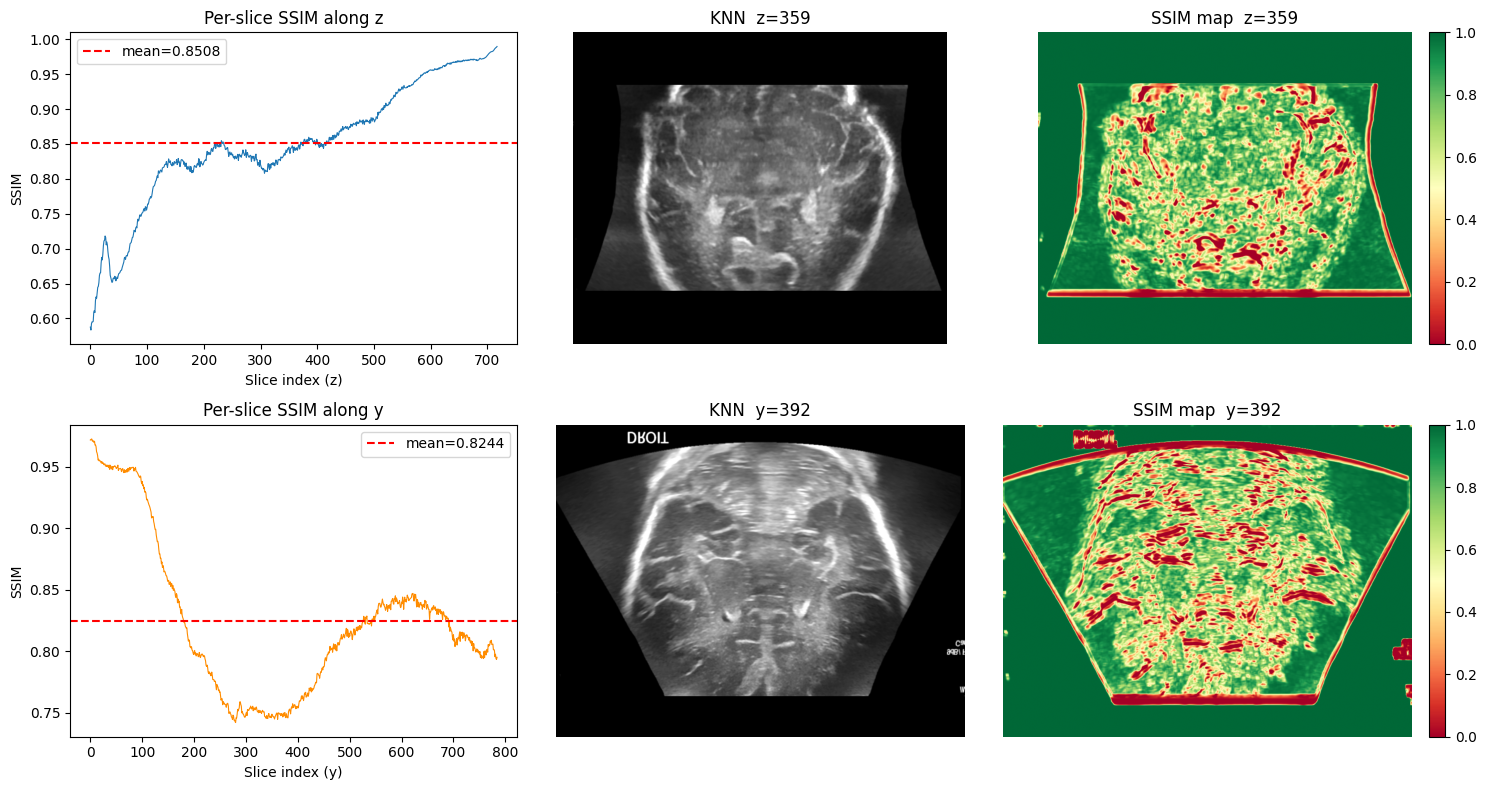

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# -------------------------------------------------------
# Both volumes may have different shapes after independent cropping.
# Align by taking the minimum size along each axis (top-left corner).
# -------------------------------------------------------
knn  = volume_cropped_knn.astype(np.float32)
nerf = volume_cropped_nerf.astype(np.float32)

print(f"volume_cropped_knn  shape: {knn.shape}")
print(f"volume_cropped_nerf shape: {nerf.shape}")

min_z = min(knn.shape[0], nerf.shape[0])
min_y = min(knn.shape[1], nerf.shape[1])
min_x = min(knn.shape[2], nerf.shape[2])

knn_aligned  = knn [:min_z, :min_y, :min_x]
nerf_aligned = nerf[:min_z, :min_y, :min_x]

print(f"\nAligned to common shape: {knn_aligned.shape}  (z, y, x)")

# -------------------------------------------------------
# Global data range across both volumes
# -------------------------------------------------------
data_range = max(knn_aligned.max(), nerf_aligned.max()) - min(knn_aligned.min(), nerf_aligned.min())

# -------------------------------------------------------
# 3-D SSIM (single global value)
# -------------------------------------------------------
ssim_3d, ssim_map_3d = ssim(
    knn_aligned, nerf_aligned,
    data_range=data_range,
    win_size=7,
    full=True,
)
print(f"\nGlobal 3-D SSIM (KNN vs NeRF): {ssim_3d:.4f}")

# -------------------------------------------------------
# Per-slice SSIM along z axis
# -------------------------------------------------------
ssim_per_z = np.array([
    ssim(knn_aligned[z], nerf_aligned[z], data_range=data_range, win_size=7)
    for z in range(min_z)
])
print(f"Per-slice (z) SSIM — mean: {ssim_per_z.mean():.4f}  min: {ssim_per_z.min():.4f}  max: {ssim_per_z.max():.4f}")

# -------------------------------------------------------
# Per-slice SSIM along y axis
# -------------------------------------------------------
ssim_per_y = np.array([
    ssim(knn_aligned[:, y, :], nerf_aligned[:, y, :], data_range=data_range, win_size=7)
    for y in range(min_y)
])
print(f"Per-slice (y) SSIM — mean: {ssim_per_y.mean():.4f}  min: {ssim_per_y.min():.4f}  max: {ssim_per_y.max():.4f}")

# -------------------------------------------------------
# Visualise
# -------------------------------------------------------
mid_z = min_z // 2
mid_y = min_y // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- z-axis row ---
axes[0, 0].plot(ssim_per_z, linewidth=0.8)
axes[0, 0].axhline(ssim_per_z.mean(), color="red", linestyle="--", label=f"mean={ssim_per_z.mean():.4f}")
axes[0, 0].set_xlabel("Slice index (z)")
axes[0, 0].set_ylabel("SSIM")
axes[0, 0].set_title("Per-slice SSIM along z")
axes[0, 0].legend()

axes[0, 1].imshow(knn_aligned[mid_z], cmap="gray")
axes[0, 1].set_title(f"KNN  z={mid_z}")
axes[0, 1].axis("off")

im0 = axes[0, 2].imshow(ssim_map_3d[mid_z], cmap="RdYlGn", vmin=0, vmax=1)
axes[0, 2].set_title(f"SSIM map  z={mid_z}")
axes[0, 2].axis("off")
plt.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

# --- y-axis row ---
axes[1, 0].plot(ssim_per_y, linewidth=0.8, color="darkorange")
axes[1, 0].axhline(ssim_per_y.mean(), color="red", linestyle="--", label=f"mean={ssim_per_y.mean():.4f}")
axes[1, 0].set_xlabel("Slice index (y)")
axes[1, 0].set_ylabel("SSIM")
axes[1, 0].set_title("Per-slice SSIM along y")
axes[1, 0].legend()

axes[1, 1].imshow(knn_aligned[:, mid_y, :], cmap="gray")
axes[1, 1].set_title(f"KNN  y={mid_y}")
axes[1, 1].axis("off")

im1 = axes[1, 2].imshow(ssim_map_3d[:, mid_y, :], cmap="RdYlGn", vmin=0, vmax=1)
axes[1, 2].set_title(f"SSIM map  y={mid_y}")
axes[1, 2].axis("off")
plt.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("ssim_knn_vs_nerf.png", dpi=150, bbox_inches="tight")
plt.show()
